# NDVI vs Chlorophyll-a Analysis

Scatter plots comparing NDVI (740 nm definition) to chlorophyll-a and related pigments from field spectrometer data.
Includes analysis by site, round, and includes Chla:Phta ratio comparisons.

> No SAS URL or token is stored in this notebook.

## 1. Imports and setup

In [ ]:
from pathlib import Path
import os
import sys

import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
import matplotlib as mpl
import seaborn as sns
from scipy.stats import linregress

project_root = Path("../..").resolve()
sys.path.insert(0, (Path(project_root).parent / "hatfield-shared-functions").as_posix())

import hatfield_funcs as hf

# project_root = Path("../..").resolve()
sys.path.insert(0, str(project_root / "src"))

from biofilm_spectra.processing.micasense import *
from biofilm_spectra.processing.spectral_matrix import to_spectral_matrix
from my_extra_to_hatfield_funcs.io_funcs import *

plt.style.use("default")
%config InlineBackend.figure_format = "retina"

pd.set_option("display.max_columns", 120)

## 2. Azure configuration

In [ ]:
STORAGE_ACCOUNT_NAME = "geoanalytics"
CONTAINER_NAME = "wesa-fup-restricted-027817p"

if os.getenv("GA_STORAGE_ACCOUNT_NAME") is not None:
    hf.config.configure_azure()
    hf.config.configure_data_root_path(CONTAINER_NAME)
else:
    raise Exception(
        "This notebook is configured to run in the cloud. Please set up your Azure storage account."
    )

## 3. Parameters

In [ ]:
SITES = ["brunswick", "westham"]

# Chlorophyll-a columns and units
CHLA_COLUMNS_NEW_UNIT = 'mg/m2'
CHLA_COLUMNS_ORIG_UNIT = 'mg/g'


# Chlorophyll-a columns to plot on y-axis
CHLA_Y_COLS = ['Chla', 'Chla + allomers', 'Total Chla']

# NDVI columns to plot on x-axis
NDVI_X_COLS = 'NDVI740'# 'NDVI717', 'NDVI_705'])

# Scatter plot visual encoding
COLOR_COL = 'Chla:Phta'  # column used to colour markers; computed in combine step
SIZE_COL  = 'Moisture (%)'

# Pigment and fatty acid lists for reference
PIGMENT_LIST = [
    "Peri", "Chlc2", "Fuco", "Ddx", "Allo", "Myxo", "Lut", "Zea",
    "Cant", "Chlb", "Chl_allo1", "Chl_allo2", "Chla", "DVCh-a", "Echi",
    "Phtb", "Phta", "Acar", "Beta",
]

# Output directory for scatter plots
OUTPUT_DIR = Path("./outputs/scatter_plots_ndvi_vs_chla")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# GNSS points with emergence times
path_gnss_with_emergence = Path(
    "data/raw_clean/gnss/biofilm_station_all_gnss_points_with_emergence_times.geojson"
)

## 4. Load data

In [ ]:
# Load lab data (preprocessed with both mg/g and mg/m2 values)
path_lab_clean = Path("data/processed/lab/lab_data_clean_new_units.csv")

df_lab = read_df_from_csv(path_lab_clean, index_col=[0, 1, 2])

print(f"Lab data shape: {df_lab.shape}")
print(f"Stations with data: {df_lab.index.get_level_values('station_id').nunique()}")
print(f"Available units: {set([col.split('(')[-1].strip(')') for col in df_lab.columns if '(' in col])}")

df_lab.head()

In [ ]:
# Spectrometers

# Load spectra and compute indices
path_spectra_processed = Path("data/processed/spectra")

df_reflectance_spectra_with_metadata = pd.DataFrame()
scan_cols = ["station_id", "round", "sample_type", "scan_id", "pair_id"] # Column to extract when converting the dataframe from parquet

for site in SITES:
    path_parquet = (
        path_spectra_processed
        / f"{site}_reflectance_common_wavelengths_scans.parquet"
    )
    df_reflectance_spectra_with_metadata_site = read_df_from_parquet(path_parquet)
    df_reflectance_spectra_with_metadata = pd.concat(
        [
            df_reflectance_spectra_with_metadata,
            df_reflectance_spectra_with_metadata_site,
        ],
        ignore_index=True,
    )
# This dataframe contains the individual reflectance spectra for all sites
df_reflectance_spectra_with_metadata.head()



In [ ]:
# Transform to a spectral matrix format for easier analysis, without the metadata, subset to our round of interest
df_reflectance_spectra = to_spectral_matrix(df_reflectance_spectra_with_metadata, scan_cols=scan_cols)

# # This dataframe contains the individual reflectance spectra, with wavelength as index
# and some column levels including 'station_id', 'round', and 'sample_type', common to all
df_reflectance_spectra.head()


In [ ]:
# Compute mean acquisition time per station/round/sample_type from scan-level metadata
df_mean_acquisition_time = (
    df_reflectance_spectra_with_metadata
    .groupby(["station_id", "round", "sample_type"])["acquisition_time_local"]
    .agg("mean")
    .to_frame()
)
df_mean_acquisition_time["acquisition_time_day_of_sampling"] = (
    df_mean_acquisition_time["acquisition_time_local"].dt.hour
    + df_mean_acquisition_time["acquisition_time_local"].dt.minute / 60
    + df_mean_acquisition_time["acquisition_time_local"].dt.second / 3600
)
df_mean_acquisition_time.head()

In [ ]:
# Load GNSS emergence times and compute time-of-sampling after emergence
gdf_emergence_times = read_geojson(path_gnss_with_emergence)

df_emergence_times = (
    gdf_emergence_times.query("corner == 'SW'")
    .filter(["station_name", "round", "emergence_time_day_of_sampling"])
    .rename(columns={"station_name": "station_id"})
    .set_index(["station_id", "round"])
)

# Duplicate for both R and S sample types to match the combined dataframe index
df_emergence_times = pd.concat(
    [df_emergence_times.assign(sample_type="R"), df_emergence_times.assign(sample_type="S")]
)
df_emergence_times = df_emergence_times.set_index("sample_type", append=True)

df_times = df_mean_acquisition_time.join(df_emergence_times, how="inner").drop(
    columns=["acquisition_time_local"]
)
df_times["time_of_sampling_after_emergence"] = (
    df_times["acquisition_time_day_of_sampling"]
    - df_times["emergence_time_day_of_sampling"]
)
df_times.head()

In [ ]:
df_reflectance_spectra_micasense_10B = resample_spectra_to_micasense_10B(
    df_reflectance_spectra
)
df_reflectance_spectra_micasense_10B.head()

In [ ]:
# Compute indices

df_indices = pd.DataFrame(index=df_reflectance_spectra_micasense_10B.columns)
df_indices["NDVI740"] = compute_ndvi740(df_reflectance_spectra_micasense_10B)
#df_indices["NDVI740"] = compute_ndvi717(df_reflectance_spectra_micasense_10B)
# df_indices["NDVI842"] = compute_ndvi842(df_reflectance_spectra_micasense_10B)
# df_indices["NDCI3"] = compute_ndci3(df_reflectance_spectra_micasense_10B)
# df_indices["NDCI2"] = compute_ndci2(df_reflectance_spectra_micasense_10B)
print(df_indices.shape)
df_indices.head()


In [ ]:
df_indices_stat = df_indices.groupby(["station_id", "round", "sample_type"]).agg(
    ["mean", "std"]
)
df_indices_stat.columns.names = ["index", "stat"]
df_indices_stat.head()

# Extract NDVI740 only as a focus
df_ndvi = df_indices_stat.xs("NDVI740", level="index", axis=1).rename(columns={"mean": "NDVI740_mean", "std": "NDVI740_std"})
df_ndvi.head()


In [ ]:
# Combine lab data with NDVI indices and emergence times
df_combined = df_lab.join(df_ndvi, how='inner')
df_combined = df_combined.join(
    df_times[["time_of_sampling_after_emergence", "acquisition_time_day_of_sampling", "emergence_time_day_of_sampling"]],
    how='left'
)

# Filter to sample type 'R' only
df_combined = df_combined.xs('R', level='sample_type', axis=0, drop_level=False)

#add pht-a to total chl-a
# Create combined column: Chla + allomers + Phta
df_combined["Chla + allomers + Phta (mg/m2)"] = (
df_combined["Chla + allomers (mg/m2)"] + df_combined["Phta (mg/m2)"]
)
df_combined["Chla + allomers + Phta (mg/g)"] = (
df_combined["Chla + allomers (mg/g)"] + df_combined["Phta (mg/g)"]
)

df_combined["Chla + Phta (mg/g)"] = (
    df_combined["Chla (mg/g)"] + df_combined["Phta (mg/g)"]
)

df_combined["Chla + Phta (mg/m2)"] = (
    df_combined["Chla (mg/m2)"] + df_combined["Phta (mg/m2)"]
)

print(f"Combined data shape: {df_combined.shape}")
print(f"Rounds available: {df_combined.index.get_level_values('round').unique().tolist()}")
print(f"Stations: {df_combined.index.get_level_values('station_id').unique().tolist()}")

## Plot individual mean spectra in selected stations to examine

In [ ]:
def plot_multiple_mean_spectra(
    df_spectra,
    df_combined,
    station_rounds,
    sample_type="R",
    figsize=(14, 7),
    title=None,
    cmap="tab10",
    title_fontsize=16,
    axis_fontsize=16,
    legend_fontsize=16,
    all_chla =False,
    unit = "mg/g",
):
    """
    Plot mean reflectance spectra for multiple stations/rounds on a single plot.

    Parameters
    ----------
    df_spectra : DataFrame
        Spectral matrix with wavelengths as index and multi-level columns
    df_combined : DataFrame
        Combined lab data with station_id, round, sample_type indices
    station_rounds : list of tuples
        List of (station_id, round_num) tuples to plot
        Example: [('B1', 1), ('B1', 2), ('B4', 1), ('W1', 2)]
    sample_type : str
        Sample type, default 'R'
    figsize : tuple
        Figure size
    title : str, optional
        Custom title
    cmap : str
        Colormap name for cycling through colors

    Returns
    -------
    fig, ax : Matplotlib figure and axes
    """
    fig, ax = plt.subplots(figsize=figsize)

    # Get colormap
    colormap = mpl.colormaps[cmap]
    num_colors = max(len(station_rounds), 3)
    colors = [colormap(i / num_colors) for i in range(len(station_rounds))]

    # Line styles to further distinguish plots
    line_styles = ["-", "--", "-.", ":"]

    for idx, (station_id, round_num) in enumerate(station_rounds):
        # Filter spectra to the requested station, round, and sample type
        cols_to_plot = df_spectra.columns.get_level_values("station_id") == station_id
        cols_to_plot &= df_spectra.columns.get_level_values("round") == round_num
        cols_to_plot &= (
            df_spectra.columns.get_level_values("sample_type") == sample_type
        )

        df_station_spectra = df_spectra.loc[:, cols_to_plot]

        if df_station_spectra.empty:
            print(
                f"Warning: No spectra found for {station_id}, round {round_num}, sample type {sample_type}"
            )
            continue

        # Get chl-a and NDVI data from df_combined
        try:
            chl_a_row = df_combined.loc[(station_id, round_num, sample_type)]

            ndvi_value = chl_a_row.get("NDVI740_mean", np.nan)

            # Determine display unit
            display_unit = unit
            unit_multiplier = 1.0
            if unit == "mg/g":
                display_unit = "ng/g"
                unit_multiplier = 1e6  # Convert mg/g to ng/g

            if all_chla:
                chla_columns = [
                    col
                    for col in df_combined.columns
                    if "Chla" in col and f"({unit})" in col
                ]
                chla_values = {
                    col: chl_a_row.get(col, np.nan) * unit_multiplier
                    for col in chla_columns
                }
            else:
                chla_value = chl_a_row.get(f"Chla ({unit})", np.nan) * unit_multiplier

            if all_chla:
                chla_str = ", ".join(
                    [
                        f"{col.replace(f' ({unit})', '')}={chla_values[col]:.2f}"
                        for col in chla_columns
                    ]
                )
            else:
                chla_str = f"{chla_value:.2f}" if not np.isnan(chla_value) else "N/A"
            ndvi_str = f"{ndvi_value:.3f}" if not np.isnan(ndvi_value) else "N/A"
        except KeyError:
            chla_str = "N/A"
            ndvi_str = "N/A"

        # Compute mean reflectance across all scans
        mean_reflectance = df_station_spectra.mean(axis=1)
        std_reflectance = df_station_spectra.std(axis=1)

        wavelengths = df_station_spectra.index

        # Use different line styles if we have more plots than colors
        line_style = line_styles[idx % len(line_styles)]
        color = colors[idx]

        # Plot mean and uncertainty
        ax.plot(
            wavelengths,
            mean_reflectance,
            linestyle=line_style,
            linewidth=2.5,
            color=color,
            label=f"{station_id} (R{round_num}, Chl-a {display_unit} {chla_str}, NDVI740={ndvi_str})",
            alpha=0.85,
        )
        ax.fill_between(
            wavelengths,
            mean_reflectance - std_reflectance,
            mean_reflectance + std_reflectance,
            alpha=0.15,
            color=color,
        )

    ax.set_xlabel("Wavelength (nm)", fontsize=axis_fontsize)
    ax.set_ylabel("Reflectance", fontsize=axis_fontsize)
   # ax.set_title(title or "Mean station reflectance", fontsize=title_fontsize)
    ax.grid(alpha=0.3)
    ax.set_xlim(400, 900)
    ax.legend(loc="best", fontsize=legend_fontsize)

    # Make tick labels bigger
    ax.tick_params(axis='both', which='major', labelsize=axis_fontsize - 2)

    fig.tight_layout()

    return fig, ax


In [ ]:
station_rounds = [
    ("B25", 2),
    ("B26", 2),
    ("B11", 2),
    ("B7", 2),
]

fig, ax = plot_multiple_mean_spectra(
    df_reflectance_spectra,
    df_combined,
    station_rounds=station_rounds,
    figsize=(16, 8),
    title_fontsize=20,
    axis_fontsize=20,
    legend_fontsize=14,
    all_chla=False,
    unit="mg/m2"
)
ax.set_ylim(0.02, 0.15)
plt.show()


## 5. Plotting functions

In [ ]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from adjustText import adjust_text
from matplotlib.lines import Line2D
from scipy.stats import linregress


def scatter_plot_with_error_bars(
    df,
    site,
    round_num,
    x_col,
    y_col,
    x_err_col=None,
    y_err_col=None,
    color_col=None,
    size_col=None,
    size_range=(40, 250),
    fit_linear_regression=False,
    regression_color="black",
    annotate_station_ids=False,
    annotation_fontsize=8,
    annotation_time_limit=2,
    annotation_extra_cols=None,
    annotation_separator="\n",
    annotation_number_format=".2f",
    title=None,
    xlabel=None,
    ylabel=None,
    cmap="viridis",
    clabel=None,
    include_s_sample_type=False,
    marker_by_round=False,
):
    """
    Create a scatter plot with optional error bars, marker color, marker size,
    linear regression, and automatically positioned station labels.

    Parameters
    ----------
    df : DataFrame
        Input data with MultiIndex (station_id, round, sample_type).
    site : str
        Site prefix to filter by (e.g., "brunswick", "westham"). Use "ALL" for all sites.
    round_num : int or list
        Round(s) to plot. Single int or list of ints.
    x_col : str
        DataFrame column name for x-axis values.
    y_col : str
        DataFrame column name for y-axis values.
    x_err_col : str, optional
        Column name for x-axis error magnitudes. Default None.
    y_err_col : str, optional
        Column name for y-axis error magnitudes. Default None.
    color_col : str, optional
        Column name for numeric values to encode as marker color. Creates colorbar.
        Default None (colors cycle by date).
    size_col : str, optional
        Column name for numeric values to encode as marker size. Creates size legend.
        Default None.
    size_range : tuple, optional
        (min_size, max_size) in points². Default (40, 250).
    fit_linear_regression : bool, optional
        If True, fits and plots OLS regression line. Default False.
    regression_color : str, optional
        Color for regression line and stats box. Default "black".
    annotate_station_ids : bool, optional
        If True, adds text labels at each point. Default False.
    annotation_fontsize : int, optional
        Font size for station labels in points. Default 8.
    annotation_time_limit : float, optional
        Max seconds for label positioning optimization. Default 2.
    annotation_extra_cols : str or list, optional
        Additional columns to append to station labels. Use "round" for round number.
        Default None.
    annotation_separator : str, optional
        String joining label parts. Default "\n" (newline).
    annotation_number_format : str, optional
        Python format string for numeric annotation values (e.g., ".1f"). Default ".2f".
    title : str, optional
        Plot title. If None, auto-generates from site and round. Default None.
    xlabel : str, optional
        Custom x-axis label. If None, uses x_col. Default None.
    ylabel : str, optional
        Custom y-axis label. If None, uses y_col. Default None.
    cmap : str, optional
        Matplotlib colormap name. Used only if color_col specified. Default "viridis".
    clabel : str, optional
        Colorbar label. If None, uses color_col. Default None.
    include_s_sample_type : bool, optional
        If True, includes sample_type='S'. If False, filters to 'R' only. Default False.
    marker_by_round : bool, optional
        If True, marker shape encodes round. If False, encodes sample date. Default False.

    Returns
    -------
    fig : matplotlib.figure.Figure
        The figure object.
    ax : matplotlib.axes.Axes
        The axes object.

    Notes
    -----
    - Input DataFrame must have MultiIndex (station_id, round, sample_type)
    - Non-finite x/y values automatically excluded from plotting
    - Regression fits OLS on valid points; error columns ignored in fitting
    - Special value: "round" in annotation_extra_cols automatically extracts and displays round
    - Station labels automatically repositioned to avoid overlaps using adjustText library
    - Legends positioned right (x=1.03); colorbar positioned below (pad=0.12)
    """

    # ----------------------------------------------------------
    # Validate input
    # ----------------------------------------------------------
    if not isinstance(site, str) or not site.strip():
        raise ValueError("site must be a non-empty string.")

    if size_range[0] <= 0:
        raise ValueError("The minimum marker size must be greater than zero.")

    if size_range[1] <= size_range[0]:
        raise ValueError("size_range must be ordered as (minimum_size, maximum_size).")

    # Normalise the extra annotation columns to a list.
    if annotation_extra_cols is None:
        annotation_extra_cols = []
    elif isinstance(annotation_extra_cols, str):
        annotation_extra_cols = [annotation_extra_cols]
    else:
        annotation_extra_cols = list(annotation_extra_cols)

    # ----------------------------------------------------------
    # Select the requested round(s)
    # ----------------------------------------------------------
    if isinstance(round_num, (list, tuple, np.ndarray, pd.Index)):
        round_nums = list(round_num)
    else:
        round_nums = [round_num]

    frames = []
    for r in round_nums:
        try:
            df_round = df.xs(r, level="round").copy()
        except KeyError:
            continue

        if "station_id" not in df_round.index.names:
            raise ValueError("'station_id' must be an index level.")

        station_ids = df_round.index.get_level_values("station_id").astype(str)

        if site != "ALL":
            site_mask = station_ids.str.startswith(site[0].upper())
            df_round = df_round.loc[site_mask].copy()

        if df_round.empty:
            continue

        if not include_s_sample_type:
            df_round = df_round.loc[
                df_round.index.get_level_values("sample_type") != "S"
            ].copy()

        df_round["_plot_round"] = r
        frames.append(df_round)

    if not frames:
        raise ValueError(f"No data found for site {site!r}, rounds={round_nums}.")

    df_plot = pd.concat(frames, axis=0)
    df_plot["_plot_round_label"] = df_plot["_plot_round"].astype(str)

    # Make 'round' available as a column for annotations if requested
    if "round" in annotation_extra_cols and "round" not in df_plot.columns:
        df_plot["round"] = df_plot["_plot_round"]

    # ----------------------------------------------------------
    # Validate required columns
    # ----------------------------------------------------------
    required_columns = [
        x_col,
        y_col,
        "Sample Date",
    ]

    if x_err_col is not None:
        required_columns.append(x_err_col)

    if y_err_col is not None:
        required_columns.append(y_err_col)

    if color_col is not None:
        required_columns.append(color_col)

    if size_col is not None:
        required_columns.append(size_col)

    required_columns.extend(annotation_extra_cols)

    missing_columns = [
        column for column in required_columns if column not in df_plot.columns
    ]

    if missing_columns:
        raise ValueError(f"Missing required columns: {missing_columns}")

    # ----------------------------------------------------------
    # Convert x and y once
    # ----------------------------------------------------------
    df_plot["_plot_x"] = pd.to_numeric(
        df_plot[x_col],
        errors="coerce",
    )

    df_plot["_plot_y"] = pd.to_numeric(
        df_plot[y_col],
        errors="coerce",
    )

    dates = sorted(df_plot["Sample Date"].dropna().unique())

    if not dates:
        raise ValueError("No valid sample dates were found.")

    markers = [
        "o",
        "s",
        "^",
        "D",
        "v",
        "<",
        ">",
        "p",
        "*",
        "h",
    ]

    # Stable mapping from round value -> marker, using all rounds present.
    # This guarantees each round always gets the same shape (Round 1 -> "o",
    # Round 2 -> "s", ...), independent of how many rounds appear on a date.
    all_rounds = sorted(df_plot["_plot_round"].unique())
    round_to_marker = {
        r: markers[i % len(markers)] for i, r in enumerate(all_rounds)
    }

    # Wider figure to reserve space for outside legends.
    fig, ax = plt.subplots(figsize=(12, 7.5))

    # Keep annotation objects and target coordinates.
    annotation_texts = []
    annotation_x = []
    annotation_y = []

    # ----------------------------------------------------------
    # Color normalization
    # ----------------------------------------------------------
    if color_col is not None:
        df_plot["_plot_color"] = pd.to_numeric(
            df_plot[color_col],
            errors="coerce",
        )

        finite_colors = df_plot.loc[
            np.isfinite(df_plot["_plot_color"]),
            "_plot_color",
        ]

        if finite_colors.empty:
            raise ValueError(f"Column {color_col!r} contains no finite numeric values.")

        color_min = finite_colors.min()
        color_max = finite_colors.max()

        if color_min == color_max:
            color_min -= 0.5
            color_max += 0.5

        color_norm = mpl.colors.Normalize(
            vmin=color_min,
            vmax=color_max,
        )

        # Copy the colormap so the registered version is not
        # modified when setting the missing-value color.
        colormap = mpl.colormaps[cmap].copy()
        colormap.set_bad("lightgrey")

    # ----------------------------------------------------------
    # Marker-size normalization
    # ----------------------------------------------------------
    default_marker_size = 65

    minimum_marker_size, maximum_marker_size = size_range

    if size_col is not None:
        df_plot["_plot_size_value"] = pd.to_numeric(
            df_plot[size_col],
            errors="coerce",
        )

        finite_sizes = df_plot.loc[
            np.isfinite(df_plot["_plot_size_value"]),
            "_plot_size_value",
        ]

        if finite_sizes.empty:
            raise ValueError(f"Column {size_col!r} contains no finite numeric values.")

        size_min = finite_sizes.min()
        size_max = finite_sizes.max()

        def scale_marker_sizes(values):
            """
            Scale numeric values to Matplotlib marker areas.
            """
            values = np.asarray(
                values,
                dtype=float,
            )

            marker_sizes = np.full(
                values.shape,
                default_marker_size,
                dtype=float,
            )

            finite = np.isfinite(values)

            if size_min == size_max:
                marker_sizes[finite] = (minimum_marker_size + maximum_marker_size) / 2

            else:
                normalized = (values[finite] - size_min) / (size_max - size_min)

                marker_sizes[finite] = minimum_marker_size + normalized * (
                    maximum_marker_size - minimum_marker_size
                )

            return marker_sizes

        df_plot["_plot_marker_size"] = scale_marker_sizes(df_plot["_plot_size_value"])

    else:
        df_plot["_plot_marker_size"] = default_marker_size

    # ----------------------------------------------------------
    # Build the text used to annotate each point
    # ----------------------------------------------------------
    def build_point_labels(df_subset):
        """
        Build one label per row, starting from the station identifier
        and the sample type, then appending any extra columns.
        """
        labels = (
            df_subset.index.get_level_values("station_id").astype(str)
            + "-"
            + df_subset.index.get_level_values("sample_type").astype(str)
        ).to_numpy(dtype=object)

        for column in annotation_extra_cols:
            values = pd.to_numeric(df_subset[column], errors="coerce")

            if values.notna().any():
                extra = values.map(
                    lambda value: (
                        f"{value:{annotation_number_format}}"
                        if np.isfinite(value)
                        else "n/a"
                    )
                )
            else:
                extra = df_subset[column].astype(str)

            labels = labels + annotation_separator + extra.to_numpy(dtype=object)

        return labels

    # ----------------------------------------------------------
    # Plot each sample date
    # ----------------------------------------------------------
    for date_index, date in enumerate(dates):
        df_date = df_plot.loc[df_plot["Sample Date"].eq(date)].copy()

        valid_xy = np.isfinite(df_date["_plot_x"]) & np.isfinite(df_date["_plot_y"])
        df_date = df_date.loc[valid_xy]

        if df_date.empty:
            continue

        if marker_by_round:
            rounds_for_date = sorted(df_date["_plot_round"].unique())
            for r in rounds_for_date:
                df_round_date = df_date.loc[df_date["_plot_round"] == r].copy()

                x = df_round_date["_plot_x"]
                y = df_round_date["_plot_y"]
                marker = round_to_marker[r]
                marker_sizes = df_round_date["_plot_marker_size"].to_numpy()

                xerr = (
                    pd.to_numeric(
                        df_round_date[x_err_col],
                        errors="coerce",
                    )
                    if x_err_col is not None
                    else None
                )

                yerr = (
                    pd.to_numeric(
                        df_round_date[y_err_col],
                        errors="coerce",
                    )
                    if y_err_col is not None
                    else None
                )

                if color_col is None and size_col is None:
                    ax.errorbar(
                        x,
                        y,
                        xerr=xerr,
                        yerr=yerr,
                        fmt=marker,
                        linestyle="none",
                        markersize=np.sqrt(default_marker_size),
                        color=f"C{date_index % 10}",
                        markeredgecolor="black",
                        markeredgewidth=0.5,
                        label=f"{date} (Round {r})",
                        capsize=3,
                        alpha=0.9,
                        zorder=2,
                    )
                else:
                    ax.errorbar(
                        x,
                        y,
                        xerr=xerr,
                        yerr=yerr,
                        fmt="none",
                        ecolor="grey",
                        elinewidth=1,
                        capsize=3,
                        alpha=0.6,
                        zorder=1,
                    )

                    scatter_arguments = {
                        "x": x,
                        "y": y,
                        "s": marker_sizes,
                        "marker": marker,
                        "edgecolor": "black",
                        "linewidth": 0.5,
                        "alpha": 0.9,
                        "label": f"{date} (Round {r})",
                        "zorder": 2,
                    }

                    if color_col is not None:
                        scatter_arguments.update(
                            {
                                "c": df_round_date["_plot_color"],
                                "cmap": colormap,
                                "norm": color_norm,
                                "plotnonfinite": True,
                            }
                        )
                    else:
                        scatter_arguments["color"] = f"C{date_index % 10}"

                    ax.scatter(**scatter_arguments)

                if annotate_station_ids:
                    station_labels = build_point_labels(df_round_date)

                    for (
                        x_value,
                        y_value,
                        station_label,
                    ) in zip(
                        df_round_date["_plot_x"],
                        df_round_date["_plot_y"],
                        station_labels,
                    ):
                        text = ax.text(
                            x_value,
                            y_value,
                            station_label,
                            fontsize=annotation_fontsize,
                            ha="center",
                            va="center",
                            color="black",
                            zorder=5,
                        )

                        annotation_texts.append(text)
                        annotation_x.append(x_value)
                        annotation_y.append(y_value)
        else:
            x = df_date["_plot_x"]
            y = df_date["_plot_y"]

            xerr = (
                pd.to_numeric(
                    df_date[x_err_col],
                    errors="coerce",
                )
                if x_err_col is not None
                else None
            )

            yerr = (
                pd.to_numeric(
                    df_date[y_err_col],
                    errors="coerce",
                )
                if y_err_col is not None
                else None
            )

            marker = markers[date_index % len(markers)]
            marker_sizes = df_date["_plot_marker_size"].to_numpy()

            if color_col is None and size_col is None:
                ax.errorbar(
                    x,
                    y,
                    xerr=xerr,
                    yerr=yerr,
                    fmt=marker,
                    linestyle="none",
                    markersize=np.sqrt(default_marker_size),
                    color=f"C{date_index % 10}",
                    markeredgecolor="black",
                    markeredgewidth=0.5,
                    label=str(date),
                    capsize=3,
                    alpha=0.9,
                    zorder=2,
                )

            else:
                ax.errorbar(
                    x,
                    y,
                    xerr=xerr,
                    yerr=yerr,
                    fmt="none",
                    ecolor="grey",
                    elinewidth=1,
                    capsize=3,
                    alpha=0.6,
                    zorder=1,
                )

                scatter_arguments = {
                    "x": x,
                    "y": y,
                    "s": marker_sizes,
                    "marker": marker,
                    "edgecolor": "black",
                    "linewidth": 0.5,
                    "alpha": 0.9,
                    "label": str(date),
                    "zorder": 2,
                }

                if color_col is not None:
                    scatter_arguments.update(
                        {
                            "c": df_date["_plot_color"],
                            "cmap": colormap,
                            "norm": color_norm,
                            "plotnonfinite": True,
                        }
                    )

                else:
                    scatter_arguments["color"] = f"C{date_index % 10}"

                ax.scatter(**scatter_arguments)

            if annotate_station_ids:
                station_labels = build_point_labels(df_date)

                for (
                    x_value,
                    y_value,
                    station_label,
                ) in zip(
                    df_date["_plot_x"],
                    df_date["_plot_y"],
                    station_labels,
                ):
                    text = ax.text(
                        x_value,
                        y_value,
                        station_label,
                        fontsize=annotation_fontsize,
                        ha="center",
                        va="center",
                        color="black",
                        zorder=5,
                    )

                    annotation_texts.append(text)
                    annotation_x.append(x_value)
                    annotation_y.append(y_value)

    # ----------------------------------------------------------
    # Linear regression
    # ----------------------------------------------------------
    regression_box = None

    if fit_linear_regression:
        regression_data = df_plot.loc[
            np.isfinite(df_plot["_plot_x"]) & np.isfinite(df_plot["_plot_y"]),
            ["_plot_x", "_plot_y"],
        ].copy()

        if len(regression_data) < 2:
            raise ValueError(
                "At least two valid points are required to fit a linear regression."
            )

        if regression_data["_plot_x"].nunique() < 2:
            raise ValueError(
                "A regression cannot be fitted because all x values are identical."
            )

        regression = linregress(
            regression_data["_plot_x"],
            regression_data["_plot_y"],
        )

        slope = regression.slope
        intercept = regression.intercept
        r_squared = regression.rvalue**2

        x_regression = np.linspace(
            regression_data["_plot_x"].min(),
            regression_data["_plot_x"].max(),
            200,
        )

        y_regression = intercept + slope * x_regression

        ax.plot(
            x_regression,
            y_regression,
            color=regression_color,
            linestyle="--",
            linewidth=2,
            alpha=0.9,
            zorder=3,
        )

        intercept_sign = "+" if intercept >= 0 else "−"

        regression_text = (
            f"Linear regression\n"
            f"y = {slope:.3g}x "
            f"{intercept_sign} "
            f"{abs(intercept):.3g}\n"
            f"$R^2$ = {r_squared:.3f}\n"
            f"p = {regression.pvalue:.3g}\n"
            f"n = {len(regression_data)}"
        )

        regression_box = ax.text(
            0.98,
            0.98,
            regression_text,
            transform=ax.transAxes,
            ha="right",
            va="top",
            fontsize=9,
            color=regression_color,
            bbox={
                "boxstyle": "round,pad=0.4",
                "facecolor": "white",
                "edgecolor": regression_color,
                "linewidth": 0.8,
                "alpha": 0.88,
            },
            zorder=6,
        )

    # ----------------------------------------------------------
    # Colorbar outside, below the plotting axes
    # ----------------------------------------------------------
    if color_col is not None:
        scalar_mappable = mpl.cm.ScalarMappable(
            norm=color_norm,
            cmap=colormap,
        )

        scalar_mappable.set_array([])

        colorbar = fig.colorbar(
            scalar_mappable,
            ax=ax,
            orientation="horizontal",
            pad=0.12,
            fraction=0.05,
            aspect=35,
        )

        colorbar.set_label(clabel if clabel is not None else color_col)

    # ----------------------------------------------------------
    # Titles and axes
    # ----------------------------------------------------------
    ax.set_title(title or f"{site.title()} — Round {round_num}")

    ax.set_xlabel(xlabel or x_col)
    ax.set_ylabel(ylabel or y_col)

    ax.grid(alpha=0.2)

    # Reserve space on the right for the outside legends and
    # below for the horizontal colorbar.
    fig.subplots_adjust(
        right=0.70,
        bottom=(0.20 if color_col is not None else 0.12),
    )

    # ----------------------------------------------------------
    # Legends outside on the right
    # ----------------------------------------------------------
    date_handles = []
    round_handles = []

    if marker_by_round:
        # Round legend by marker shape (same mapping as the plotted points).
        for r in all_rounds:
            round_handles.append(
                Line2D(
                    [],
                    [],
                    linestyle="none",
                    marker=round_to_marker[r],
                    markersize=8,
                    markerfacecolor="grey",
                    markeredgecolor="black",
                    markeredgewidth=0.5,
                    label=f"Round {r}",
                )
            )

        # Date legend by color
        for date_index, date in enumerate(dates):
            if color_col is not None:
                marker_facecolor = "grey"
            else:
                marker_facecolor = f"C{date_index % 10}"

            date_handles.append(
                Line2D(
                    [],
                    [],
                    linestyle="none",
                    marker="o",
                    markersize=8,
                    markerfacecolor=marker_facecolor,
                    markeredgecolor="black",
                    markeredgewidth=0.5,
                    label=str(date),
                )
            )

        # Create both legends
        round_legend = ax.legend(
            handles=round_handles,
            title="Round",
            loc="upper left",
            bbox_to_anchor=(1.03, 1.0),
            borderaxespad=0,
        )
        ax.add_artist(round_legend)

        date_legend = ax.legend(
            handles=date_handles,
            title="Sample date",
            loc="upper left",
            bbox_to_anchor=(1.03, 0.65),
            borderaxespad=0,
        )
    else:
        for date_index, date in enumerate(dates):
            if color_col is not None:
                marker_facecolor = "grey"
            else:
                marker_facecolor = f"C{date_index % 10}"

            date_handles.append(
                Line2D(
                    [],
                    [],
                    linestyle="none",
                    marker=markers[date_index % len(markers)],
                    markersize=8,
                    markerfacecolor=marker_facecolor,
                    markeredgecolor="black",
                    markeredgewidth=0.5,
                    label=str(date),
                )
            )

        date_legend = ax.legend(
            handles=date_handles,
            title="Sample date",
            loc="upper left",
            bbox_to_anchor=(1.03, 1.0),
            borderaxespad=0,
        )

    # The legends are outside the main axes, so adjustText does
    # not need to avoid them.
    objects_to_avoid = []

    # ----------------------------------------------------------
    # Marker-size legend outside, below date legend
    # ----------------------------------------------------------
    size_legend = None

    if size_col is not None:
        # Preserve the first legend before creating the second.
        ax.add_artist(date_legend)

        size_legend_values = np.unique(
            np.quantile(
                finite_sizes,
                [0, 0.5, 1],
            )
        )

        size_legend_areas = scale_marker_sizes(size_legend_values)

        # Line2D uses marker diameter in points, whereas scatter
        # uses marker area in points squared.
        size_handles = [
            Line2D(
                [],
                [],
                linestyle="none",
                marker="o",
                markersize=np.sqrt(marker_area),
                markerfacecolor="grey",
                markeredgecolor="black",
                markeredgewidth=0.5,
                alpha=0.8,
                label=f"{value:.3g}",
            )
            for value, marker_area in zip(
                size_legend_values,
                size_legend_areas,
            )
        ]

        # Render the date legend so its exact height can be
        # measured.
        fig.canvas.draw()

        renderer = fig.canvas.get_renderer()

        date_legend_bbox = date_legend.get_window_extent(renderer=renderer).transformed(
            ax.transAxes.inverted()
        )

        # Place the size legend immediately below the date legend.
        size_legend_y = date_legend_bbox.y0 - 0.04

        size_legend = ax.legend(
            handles=size_handles,
            title=size_col,
            loc="upper left",
            bbox_to_anchor=(
                1.03,
                size_legend_y,
            ),
            borderaxespad=0,
        )

    # The regression statistics remain inside the axes, so
    # station annotations should avoid them.
    if regression_box is not None:
        objects_to_avoid.append(regression_box)

    # ----------------------------------------------------------
    # Automatically reposition station labels
    # ----------------------------------------------------------
    if annotate_station_ids and annotation_texts:
        # Draw the complete figure first so adjustText uses the
        # final axes dimensions and limits.
        fig.canvas.draw()

        adjust_args = {
            "texts": annotation_texts,
            "x": np.asarray(annotation_x),
            "y": np.asarray(annotation_y),
            "target_x": np.asarray(annotation_x),
            "target_y": np.asarray(annotation_y),
            "ax": ax,
            "avoid_self": True,
            "prevent_crossings": True,
            "ensure_inside_axes": True,
            "expand": (1.1, 1.25),
            "force_text": (0.2, 0.3),
            "force_static": (0.1, 0.2),
            "force_pull": (0.01, 0.01),
            "max_move": 30,
            "min_arrow_len": 4,
            "time_lim": annotation_time_limit,
            "arrowprops": {
                "arrowstyle": "-",
                "color": "grey",
                "linewidth": 0.6,
                "alpha": 0.8,
            },
        }

        # Only pass objects if there are any to avoid
        if objects_to_avoid:
            adjust_args["objects"] = objects_to_avoid

        adjust_text(**adjust_args)

    return fig, ax

In [ ]:
scatter_plot_with_error_bars(
    df_combined,
    'brunswick',
    [1,2],
    'NDVI740_mean',
    'Chla + Phta (mg/m2)',
    x_err_col=None,
    y_err_col=None,
    color_col=None,
    size_col=None,
    size_range=[20,22],
    fit_linear_regression=True,
    regression_color="black",
    annotate_station_ids=True,
    annotation_fontsize=8,
    annotation_time_limit=2,
    title=None,
    xlabel='NDVI',
    ylabel='Chl-a + Phta (mg/m2)',
    cmap="viridis",
    clabel=None,
    include_s_sample_type=False,
    marker_by_round=True
)


In [ ]:
scatter_plot_with_error_bars(
    df_combined,
    "brunswick",
    [1, 2],
    "NDVI740_mean",
    "Chla + allomers (mg/m2)",
    x_err_col=None,
    y_err_col=None,
    color_col=None,
    size_col=None,
    size_range=[20, 22],
    fit_linear_regression=True,
    regression_color="black",
    annotate_station_ids=True,
    annotation_fontsize=8,
    annotation_time_limit=2,
    title=None,
    xlabel="NDVI",
    ylabel="Chl-a + allomers (mg/m2)",
    cmap="viridis",
    clabel=None,
    include_s_sample_type=False,
    marker_by_round=True,
)


## Read in PAR data and add to plot

In [ ]:
# read in the PAR file
env_file = "/home/coder/wesa-fup-restricted/data/processed/environmental/LEG13553_PARdata2026.csv"
df_env = gpd.read_file(env_file)
df_env.head()

In [ ]:
# 1. PAR side
df_env = df_env.copy()
df_env["date_time_parsed"] = pd.to_datetime(df_env["date_time_parsed"]).astype(
    "datetime64[ns]"
)
df_env["site"] = df_env["station"].map({"PAR Brunswick": "B", "PAR Westham": "W"})

# 2. Acquisition side
df_acq = df_mean_acquisition_time.reset_index()
df_acq["acquisition_time_naive"] = (
    df_acq["acquisition_time_local"].dt.tz_localize(None).astype("datetime64[ns]")
)
df_acq["site"] = df_acq["station_id"].str[0].str.upper()

# 3. Sort by the time key, merge within site
df_acq = df_acq.sort_values("acquisition_time_naive")
df_env_sorted = df_env.sort_values("date_time_parsed")

df_acq_par = pd.merge_asof(
    df_acq,
    df_env_sorted,
    left_on="acquisition_time_naive",
    right_on="date_time_parsed",
    by="site",
    direction="nearest",
    tolerance=pd.Timedelta("15min"),
).set_index(["station_id", "round", "sample_type"])


In [ ]:
df_withpar = df_combined.join(df_acq_par, how="left", rsuffix="_par")
df_withpar.head()

In [ ]:
scatter_plot_with_error_bars(
    df_withpar,
    "brunswick",
    [1, 2],
    "NDVI740_mean",
    "Chla (mg/m2)",
    annotate_station_ids=True,
    annotation_extra_cols=["Acc_PAR_mol_m²"],
    annotation_number_format=".1f",
    marker_by_round=True,
)

In [ ]:
scatter_plot_with_error_bars(
    df_withpar,
    "westham",
    [1, 2],
    "NDVI740_mean",
    "Chla (mg/m2)",
    annotate_station_ids=True,
    annotation_extra_cols=["Acc_PAR_mol_m²"],
    annotation_number_format=".1f",
    marker_by_round=True,
)

## Check chl-a compared to ng/g in 2022

In [ ]:
#open as df
path = "/home/coder/wesa-fup-restricted/2022_Hatfield_data/new_output/april2022_biofilmdata.geojson"
df_2022 = gpd.read_file(path)
#subset where df_2022["quadrat_prefix"] is DRBF
df_2022 = df_2022[df_2022["quadrat_prefix"] == "DRBF"]


In [ ]:
df_2022.head()

In [ ]:
# path ="/home/coder/awebster/wesa-fup/confidential-leg13553-biofilm/april2022_biofilm_sampling_v2.geojson"
# df_2022_old = gpd.read_file(path)
# # subset where df_2022["quadrat_prefix"] is DRBF
# df_2022_old = df_2022_old[df_2022_old["quadrat_prefix"] == "DRBF"]


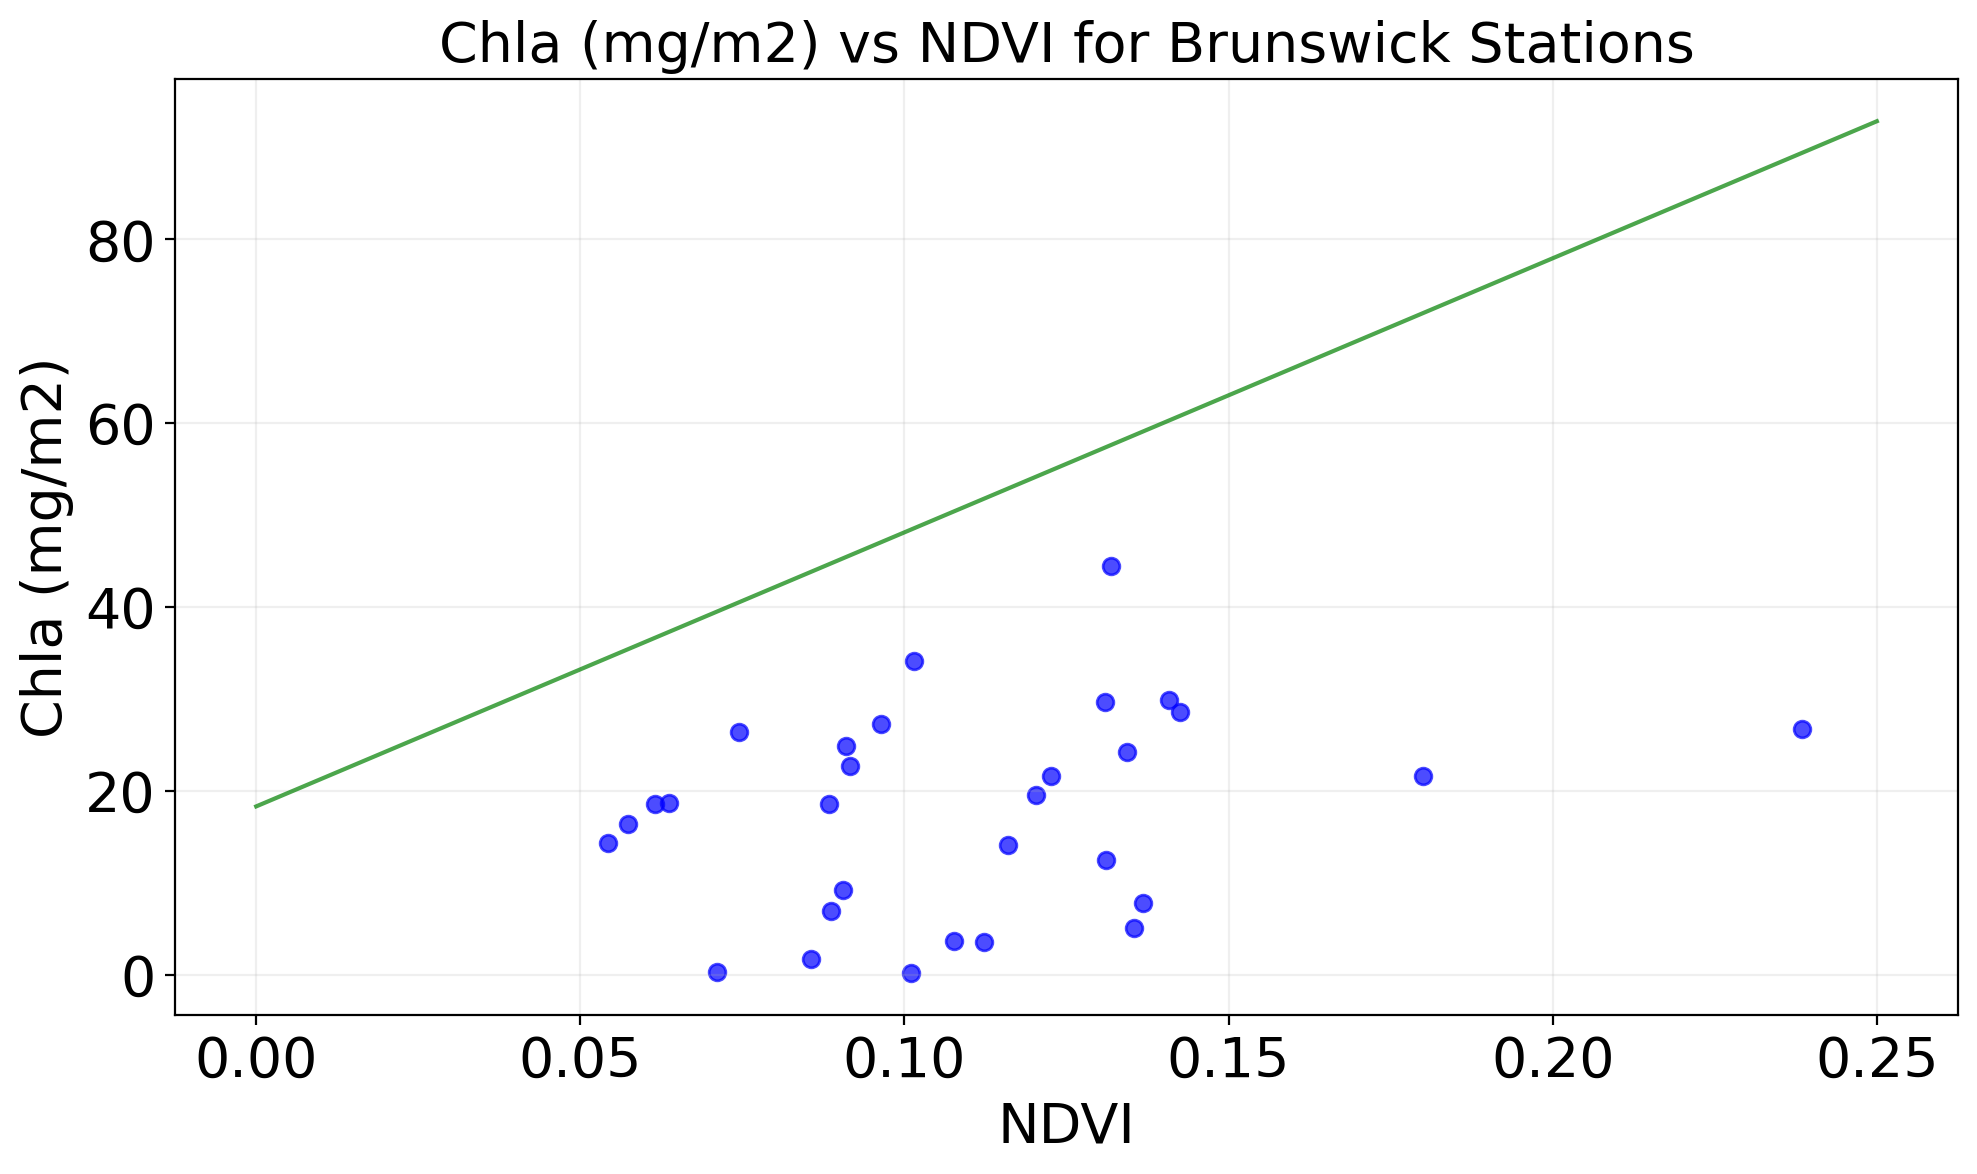

In [27]:
y_col_base = "Chla"
y_col_unit = "mg/m2"

y_col = f"{y_col_base} ({y_col_unit})"
round_num = 1

# Subset to the selected round first, then filter by station prefix on that subset
df_round = df_combined.xs(round_num, level="round").copy()
df_combined_brunswick_round1 = df_round.loc[
    df_round.index.get_level_values("station_id").str.startswith("B")
]

yvals = df_combined_brunswick_round1[y_col]
xvals = df_combined_brunswick_round1["NDVI740_mean"]

# fit from 2021
x_fit = np.array([0, 0.05, 0.1, 0.15, 0.2, 0.25])
y_fit = 18.3 + x_fit * 298.2

fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(xvals, yvals, color="blue", alpha=0.7)
ax.plot(x_fit, y_fit, color="green", alpha=0.7)
ax.set_xlabel("NDVI", fontsize=20)
ax.set_ylabel(f"{y_col_base} ({y_col_unit})", fontsize=20)
ax.set_title(f"{y_col_base} ({y_col_unit}) vs NDVI for Brunswick Stations", fontsize=20)
# set font of x and y labels to 20
ax.tick_params(axis="both", which="major", labelsize=20)
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()


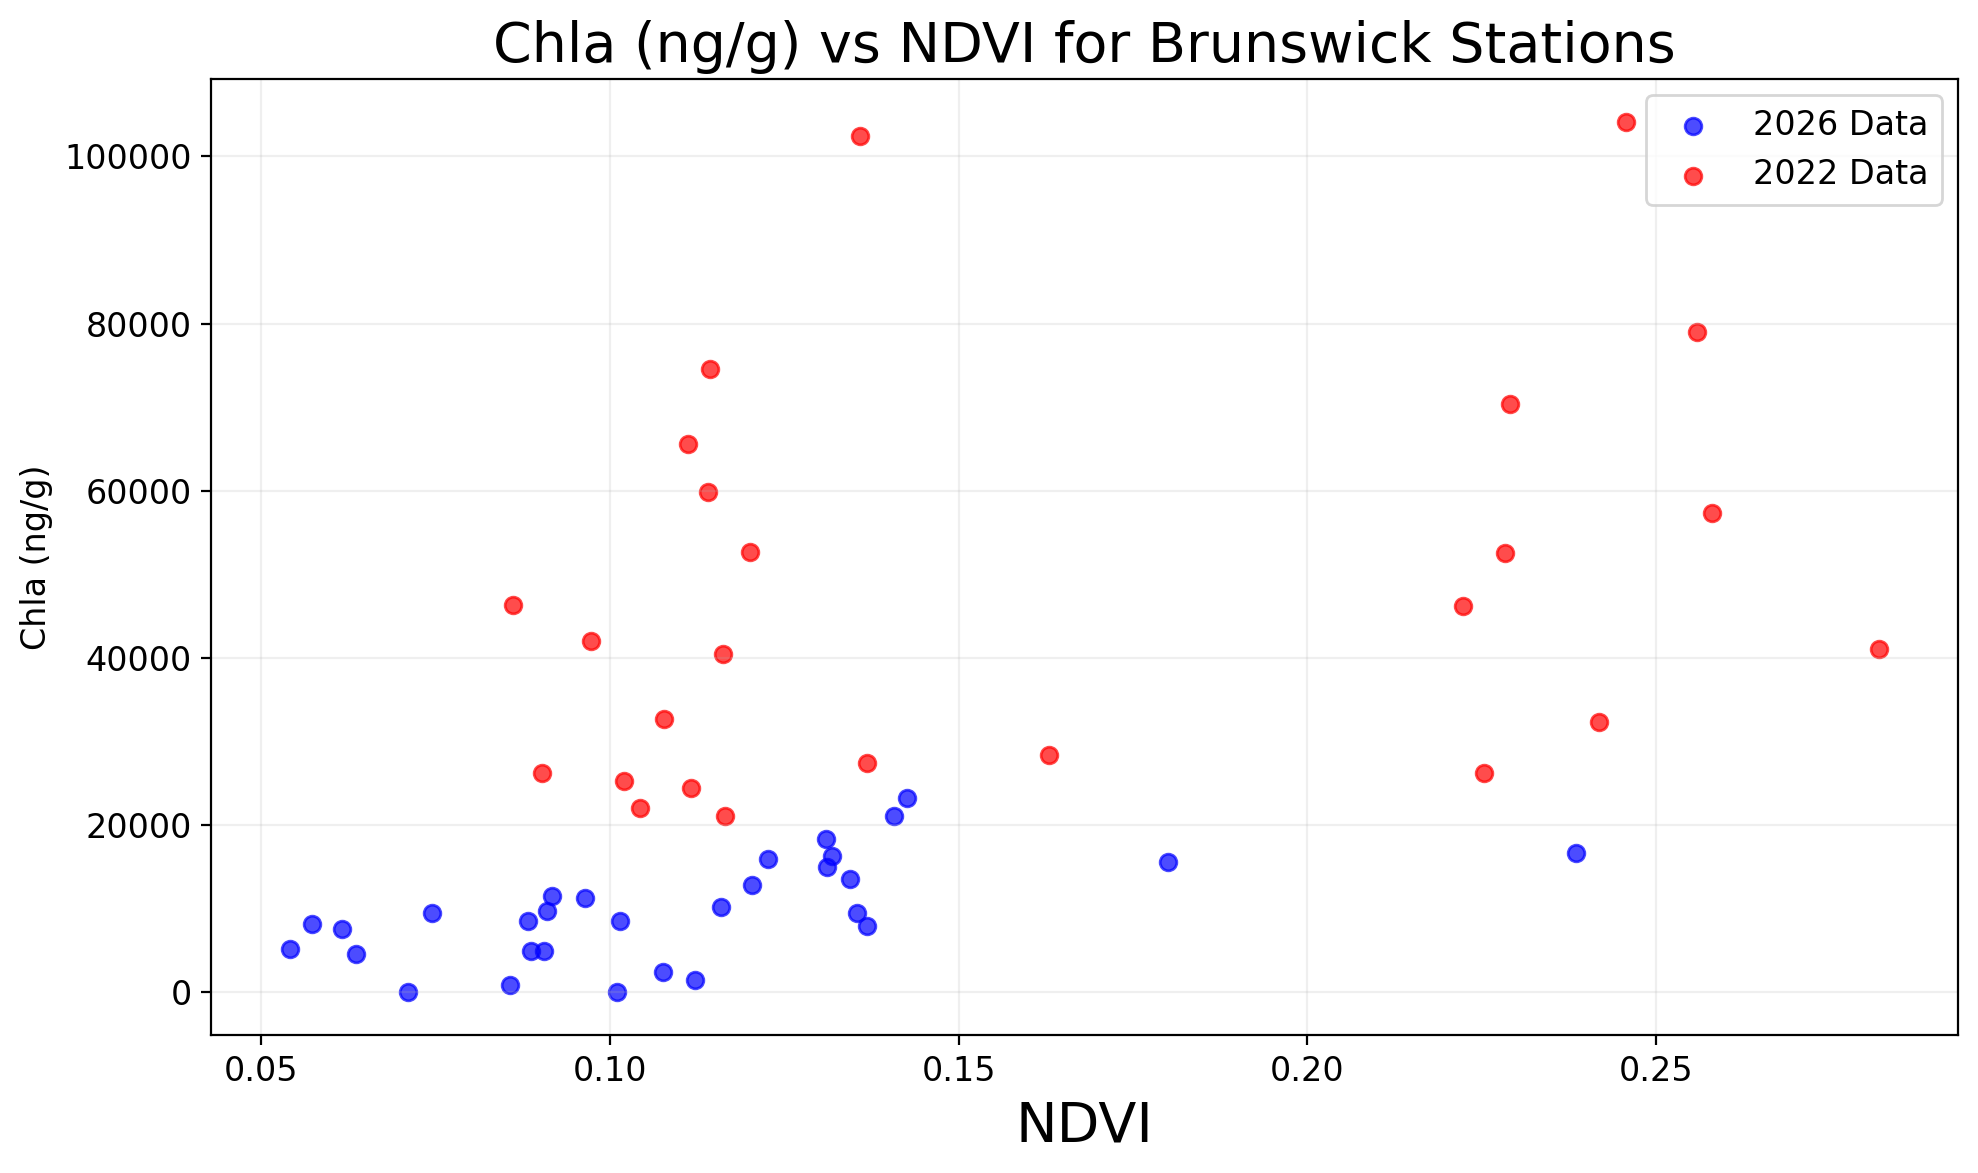

In [28]:
# Plot Chl-a (mg/g) vs NDVI740 for Brunswick stations in one round
y_col_base = "Chla"
y_col_unit = "mg/g"

y_col = f"{y_col_base} ({y_col_unit})"
round_num = 1

# Subset to the selected round first, then filter by station prefix on that subset
df_round = df_combined.xs(round_num, level="round").copy()
df_combined_brunswick_round1 = df_round.loc[
    df_round.index.get_level_values("station_id").str.startswith("B")
]

yvals = df_combined_brunswick_round1[y_col] * 1000000
xvals = df_combined_brunswick_round1["NDVI740_mean"]

# add new point to plot with yval and xvals
new_y = df_2022["Chla"]
new_x = df_2022["NDVI_msi"]


fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(xvals, yvals, color="blue", alpha=0.7)
ax.scatter(new_x, new_y, color="red", alpha=0.7)
ax.set_xlabel("NDVI", fontsize=20)
ax.set_ylabel(f"{y_col_base} (ng/g)", fontsize=12)
ax.set_title(
    f"{y_col_base} (ng/g) vs NDVI for Brunswick Stations",fontsize =20
)
#legend - blue is 2026 data, red is 2022 data
ax.legend(["2026 Data", "2022 Data"],fontsize=12)
#set font of x and y labels to 20
ax.tick_params(axis='both', which='major', labelsize=12)
from matplotlib.ticker import MultipleLocator

ax.xaxis.set_major_locator(MultipleLocator(0.05))
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

## TEST PLS

In [29]:
from sklearn.cross_decomposition import PLSRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import cross_val_predict, LeaveOneOut


In [30]:
def optimise_pls_cv(X, y, n_comp, cv = LeaveOneOut()):
    """
    Optimise PLS regression using cross-validation.

    Parameters:
    X : array-like, shape (n_samples, n_features)
        Predictor variables.
    y : array-like, shape (n_samples,)
        Target variable.
    n_comp : int
        Number of PLS components.
    cv : cross-validation generator, optional (default=LeaveOneOut())
        Cross-validation strategy.

    Returns:
    y_cv : array, shape (n_samples,)
        Cross-validated predictions.
    score : float
        R^2 score.
    rmse : float
        Root mean squared error.
    rpd : float
        Ratio of performance to deviation.
    """
    # Define PLS object
    pls = PLSRegression(n_components=n_comp)

    # Cross-validation
    y_cv = cross_val_predict(pls, X, y, cv=cv)

    # Calculate scores
    score = r2_score(y, y_cv)
    rmse = np.sqrt(mean_squared_error(y, y_cv))
    rpd = y.std() / rmse

    return (y_cv, score, rmse, rpd)


In [31]:
df_combined.head()

Sample Total Dry Mass (g)  \
station_id round sample_type                              
B1         1     R                           124.920787   
           2     R                           102.318373   
B10        1     R                           113.372704   
           2     R                           135.840106   
B11        1     R                            68.488373   

                              Extraction Dry Mass (mg)  Peri (mg/g)  \
station_id round sample_type                                          
B1         1     R                               554.2     0.000130   
           2     R                               512.4     0.000207   
B10        1     R                               460.8     0.000159   
           2     R                               582.7     0.000217   
B11        1     R                               480.4     0.000083   

                              Chlc2 (mg/g)  Fuco (mg/g)  Ddx (mg/g)  \
station_id round sample_type                                          
B1         1     R                0.000126     0.004335    0.003132   
           2     R                0.000324     0.005283    0.004532   
B10        1     R                0.000414     0.005671    0.003579   
           2     R                0.000197     0.004817    0.003055   
B11        1     R                0.000451     0.006007    0.004110   

                              Allo (mg/g)  Myxo (mg/g)  Lut (mg/g)  \
station_id round sample_type                                         
B1         1     R               0.000217     0.000186    0.000786   
           2     R               0.000166     0.000192    0.001309   
B10        1     R               0.000381     0.000401    0.001142   
           2     R               0.000188     0.000174    0.000865   
B11        1     R               0.000346     0.000399    0.001323   

                              Zea (mg/g)  Cant (mg/g)  Chlb (mg/g)  \
station_id round sample_type                                         
B1         1     R              0.000417     0.000036     0.000499   
           2     R              0.000386     0.000168     0.000760   
B10        1     R              0.000503     0.000288     0.000902   
           2     R              0.000480     0.000070     0.000561   
B11        1     R              0.000442     0.000300     0.001038   

                              Chl_allo1 (mg/g)  Chl_allo2 (mg/g)  Chla (mg/g)  \
station_id round sample_type                                                    
B1         1     R                    0.002102          0.000572     0.012824   
           2     R                    0.002939          0.000447     0.022951   
B10        1     R                    0.004321          0.000566     0.015630   
           2     R                    0.003894          0.001018     0.014140   
B11        1     R                    0.004738          0.000775     0.014960   

                              DVCh-a (mg/g)  Echi (mg/g)  Phtb (mg/g)  \
station_id round sample_type                                            
B1         1     R                 0.000792     0.000150     0.000470   
           2     R                 0.003293     0.000026     0.000182   
B10        1     R                 0.002136     0.000083     0.000185   
           2     R                 0.000719     0.000131     0.000315   
B11        1     R                 0.000000     0.000116     0.000359   

                              Phta (mg/g)  Acar (mg/g)  Beta (mg/g)  \
station_id round sample_type                                          
B1         1     R               0.001007     0.000480     0.000000   
           2     R               0.000885     0.000747     0.000000   
B10        1     R               0.001936     0.000279     0.000000   
           2     R               0.000784     0.000349     0.000000   
B11        1     R               0.001072     0.000398     0.000014   

                             Sample Date  Moisture (%)  Perc

In [32]:
# Prepare MSI data (MicaSense 10B) for PLS regression
# Mean MSI reflectance per station (not individual scans)
def prepare_PLS_data(df_reflectance_spectra_micasense_10B, df_combined, round_val=1, stations='all',
   y_col_base="Chla", y_col_unit="mg/m2", norm_option="sum", add_emergence_time=True):
    """
    Prepare data for PLS regression.

    Parameters:
    df_reflectance_spectra_micasense_10B : DataFrame
        Reflectance spectra data.
    df_combined : DataFrame
        Combined data with target variable.
    round_val : int, optional (default=1)
        Round number to filter the data. None to use both rounds.
    y_col_base : str, optional (default="Chla")
        Base name of the target variable in the dataframe.
    y_col_unit : str, optional (default="mg/m2")
        Unit of the target variable.
    stations : str or list, optional (default='all')
        Stations to include in the analysis. If 'all', include all stations.
        if "B" include only Brunswick stations, if "W" include only Westham stations.
    norm_option : list, optional (default=["sum"])
        Normalization option for spectra ("none", "max", "sum").
    add_emergence_time : bool, optional (default=True)
        Whether to add emergence time as an additional predictor variable.

    Returns:
    Xvals : array, shape (n_samples, n_features)
        Predictor variables.
    yvals : array, shape (n_samples,)
        Target variable.
    """
    df_msi_mean = (
        df_reflectance_spectra_micasense_10B.T.groupby(
            level=["station_id", "round", "sample_type"]
        )
        .mean()
        .T
    )

    # only use R sample type, not S (already filtered in df_combined!)
    # mask for R samples
    mask_r = df_msi_mean.columns.get_level_values("sample_type") == "R"
    df_msi_mean = df_msi_mean.loc[:, mask_r]

    # filter by stations if specified
    if stations == "B":
        mask_stations = df_msi_mean.columns.get_level_values("station_id").str.startswith("B")
        df_msi_mean = df_msi_mean.loc[:, mask_stations]
    elif stations == "W":
        mask_stations = df_msi_mean.columns.get_level_values("station_id").str.startswith("W")
        df_msi_mean = df_msi_mean.loc[:, mask_stations]
    else:
        pass  # use all stations
        print(f"Using all stations for PLS regression.")

    # extract round  or use all
    if round_val == 1:
        print(f"Using round {round_val} for PLS regression.")
        mask_round1 = df_msi_mean.columns.get_level_values("round") == round_val
        df_msi_mean = df_msi_mean.loc[:, mask_round1]

    elif round_val == 2:
        print(f"Using round {round_val} for PLS regression.")
        mask_round2 = df_msi_mean.columns.get_level_values("round") == round_val
        df_msi_mean = df_msi_mean.loc[:, mask_round2]

    else:
        print(f"Using all rounds for PLS regression.")


    Xvals = df_msi_mean.T.values  # Shape: (n_stations, n_bands=10)

    # normalize Xvals spectra to avoid offsets
    #normalize options: none, to max of the spectrum, to sum of the spectrum

    if norm_option == "max":
        Xvals = Xvals / Xvals.max(axis=1, keepdims=True)
    elif norm_option == "sum":
        Xvals = Xvals / Xvals.sum(axis=1, keepdims=True)

    if add_emergence_time:
        msi_index = df_msi_mean.T.index
        emergence_time = df_combined.loc[msi_index, "time_of_sampling_after_emergence"].values
        Xvals = np.hstack([Xvals, emergence_time.reshape(-1, 1)])

    #get y vals as chl-a for round selected:
    msi_index = df_msi_mean.T.index # uses the round-selected only
    yvals = df_combined.loc[msi_index, f"{y_col_base} ({y_col_unit})"].values

    print(f"Predictor shape: {Xvals.shape}")  # Should be (60, 10)
    print(f"Target shape: {yvals.shape}")  # Should be (60,)

    return Xvals, yvals


In [33]:
# #loop through and plot all quadrat mean spectra in XVals (first 10 bands/values)
# for i in range(Xvals.shape[0]):
#     plt.plot(Xvals[i, :10], alpha=0.7)
# plt.xlabel("Band")
# plt.ylabel("Reflectance")
# plt.title("Station Mean Spectra (MicaSense 10B) for Round 1")
# plt.show()


In [34]:
round_val = 1
y_col_base = "Total Chla"
y_col_unit = "mg/m2"
norm_option = "sum"
add_emergence_time = True
Xvals, yvals = prepare_PLS_data(
    df_reflectance_spectra_micasense_10B,
    df_combined,
    round_val=round_val,
    y_col_base=y_col_base,
    y_col_unit=y_col_unit,
    norm_option=norm_option,
    add_emergence_time=add_emergence_time,
)
# test to see how many components to use
r2s = []
rmses = []
rpds = []
xticks = np.arange(1, 11)
for n_comp in xticks:
    y_cv, r2, rmse, rpd = optimise_pls_cv(Xvals, yvals, n_comp, cv=LeaveOneOut())
    r2s.append(r2)
    rmses.append(rmse)
    rpds.append(rpd)
    print(f"components {n_comp}, r2 {r2}, rmse {rmse}, rpd  {rpd}")

Using all stations for PLS regression.
Using round 1 for PLS regression.
Predictor shape: (60, 11)
Target shape: (60,)
components 1, r2 0.0749111708288166, rmse 10.110367800312526, rpd  1.0397005689970111
components 2, r2 0.1219697836366761, rmse 9.849857952579873, rpd  1.0671986545755978
components 3, r2 0.13987303820855068, rmse 9.748920239155952, rpd  1.0782481440902718
components 4, r2 0.07877319487045154, rmse 10.089241547353385, rpd  1.0418776382166648
components 5, r2 0.0332868400301648, rmse 10.335322955254068, rpd  1.0170707969420767
components 6, r2 0.07543466330927584, rmse 10.107506750472643, rpd  1.0399948685923408
components 7, r2 0.15022066311323068, rmse 9.690101359492425, rpd  1.0847931063648448
components 8, r2 0.1353035557381106, rmse 9.774781834786069, rpd  1.0753953727483938
components 9, r2 0.10924782045162018, rmse 9.920959651499807, rpd  1.0595502374777699
components 10, r2 0.1101417088853397, rmse 9.915980456798739, rpd  1.0600822783537025


### Plot the predections for each when left out

r2 0.15022066311323068
r 0.44148563429711113
slope 0.28819539404353484
intercept 18.351653575773685
rmse 9.690101359492425


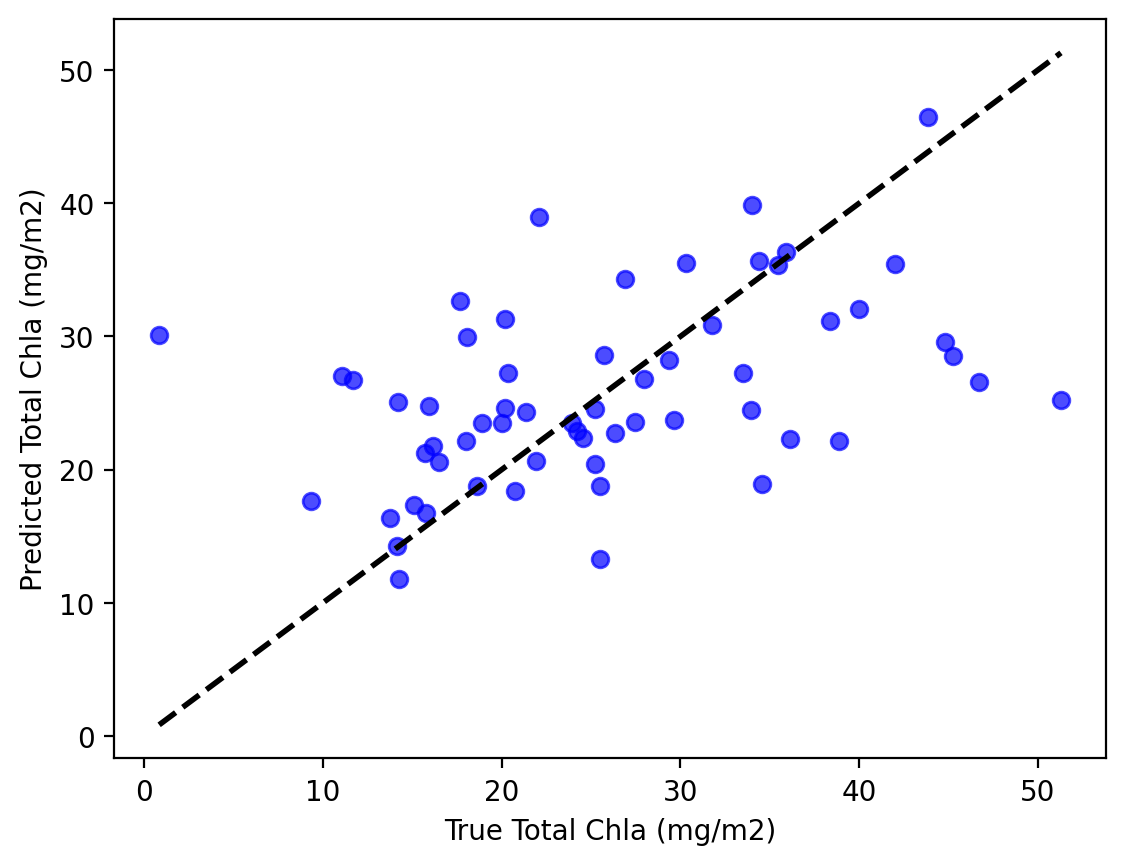

In [35]:
# check what it's predicting for each point when we do leave-one out (or other cross val)
import scipy.stats
best_n_comp = np.argmax(r2s) + 1
pred_vals, r2, mse, rpd = optimise_pls_cv(Xvals, yvals, best_n_comp, cv=LeaveOneOut())
# pred_vals2, r2_2, mse_2, rpd_2 = optimise_pls_cv(Xvals, yvals, 1, cv=LeaveOneOut())
plt.scatter(yvals, pred_vals, color="blue", alpha=0.7)

# plt.scatter(yvals, pred_vals2, color="red", alpha=0.7)
plt.xlabel(f"True {y_col_base} ({y_col_unit})")
plt.ylabel(f"Predicted {y_col_base} ({y_col_unit})")
# add the 1:1 line
plt.plot([yvals.min(), yvals.max()], [yvals.min(), yvals.max()], 'k--', lw=2)

slope, intercept, r_value, p_value, std_err = scipy.stats.linregress(yvals, pred_vals.flatten())
score = r2_score(yvals, pred_vals.flatten())
rmse = np.sqrt(mean_squared_error(yvals, pred_vals.flatten()))
print(f"r2 {score}")
print(f"r {r_value}")
print(f"slope {slope}")
print(f"intercept {intercept}")
print(f"rmse {rmse}")

### Train model with all points and apply to training data or another round

In [36]:
# now train the model and see how it does on training data - and maybe on round 2 data?
best_n_comp = np.argmax(r2s) + 1
print("best number of components:", best_n_comp)
pls_final = PLSRegression(n_components=best_n_comp)
pls_final.fit(Xvals, yvals)


best number of components: 7


,n_components,np.int64(7)
,scale,True
,max_iter,500
,tol,1e-06
,copy,True


Using all stations for PLS regression.
Using round 1 for PLS regression.
Predictor shape: (60, 11)
Target shape: (60,)
Round 1 r2 0.3833156603371448
Round 1 rmse 8.254802679672002


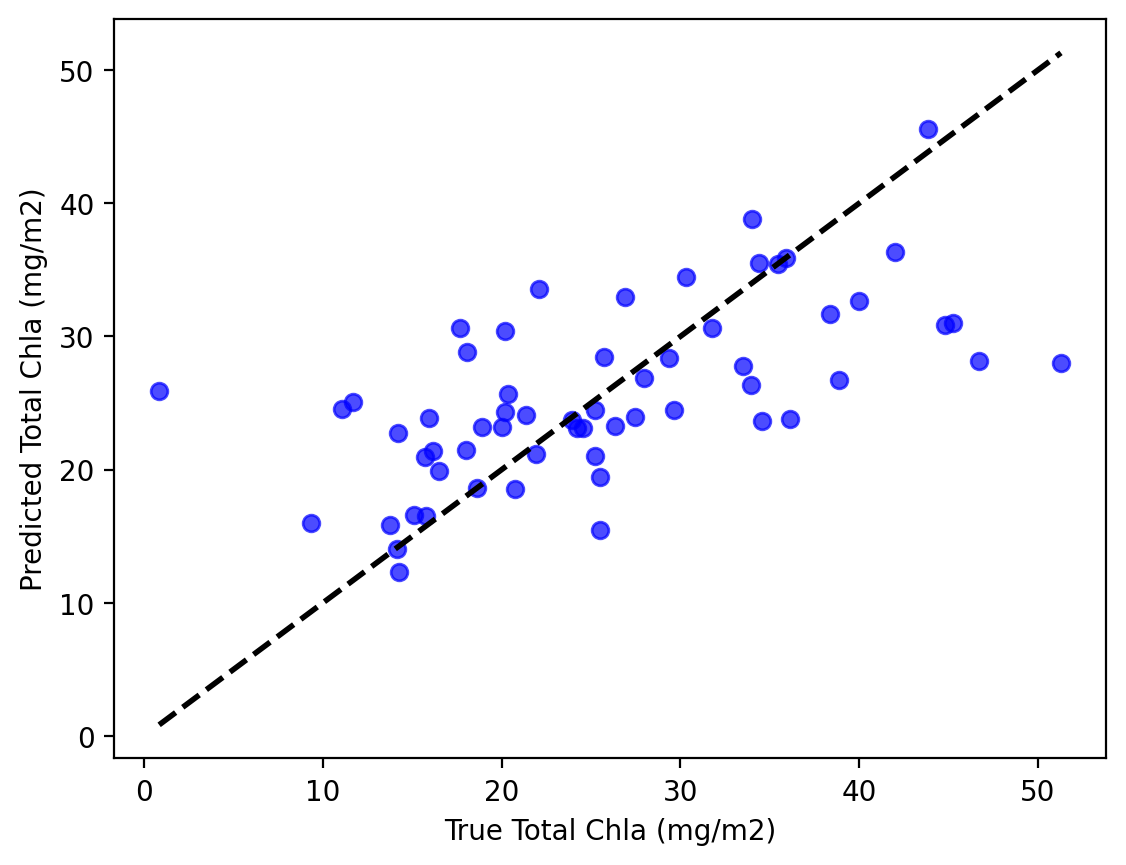

In [37]:
# predict
round_val = 1
Xvals2, yvals2 = prepare_PLS_data(
    df_reflectance_spectra_micasense_10B,
    df_combined,
    round_val=round_val,
    y_col_base=y_col_base,
    y_col_unit=y_col_unit,
    norm_option=norm_option,
    add_emergence_time=add_emergence_time,
)
predictions = pls_final.predict(Xvals2)

# plot predictions vs true values for round 2 yvals2
plt.scatter(yvals2, predictions, color="blue", alpha=0.7)
plt.xlabel(f"True {y_col_base} ({y_col_unit})")
plt.ylabel(f"Predicted {y_col_base} ({y_col_unit})")
# add the 1:1 line
plt.plot([yvals2.min(), yvals2.max()], [yvals2.min(), yvals2.max()], "k--", lw=2)

# print metrics
score2 = r2_score(yvals2, predictions.flatten())
rmse2 = np.sqrt(mean_squared_error(yvals2, predictions.flatten()))
print(f"Round {round_val} r2 {score2}")
print(f"Round {round_val} rmse {rmse2}")


CV R²: 0.15022066311323068
Training R²: 0.3833156603371448


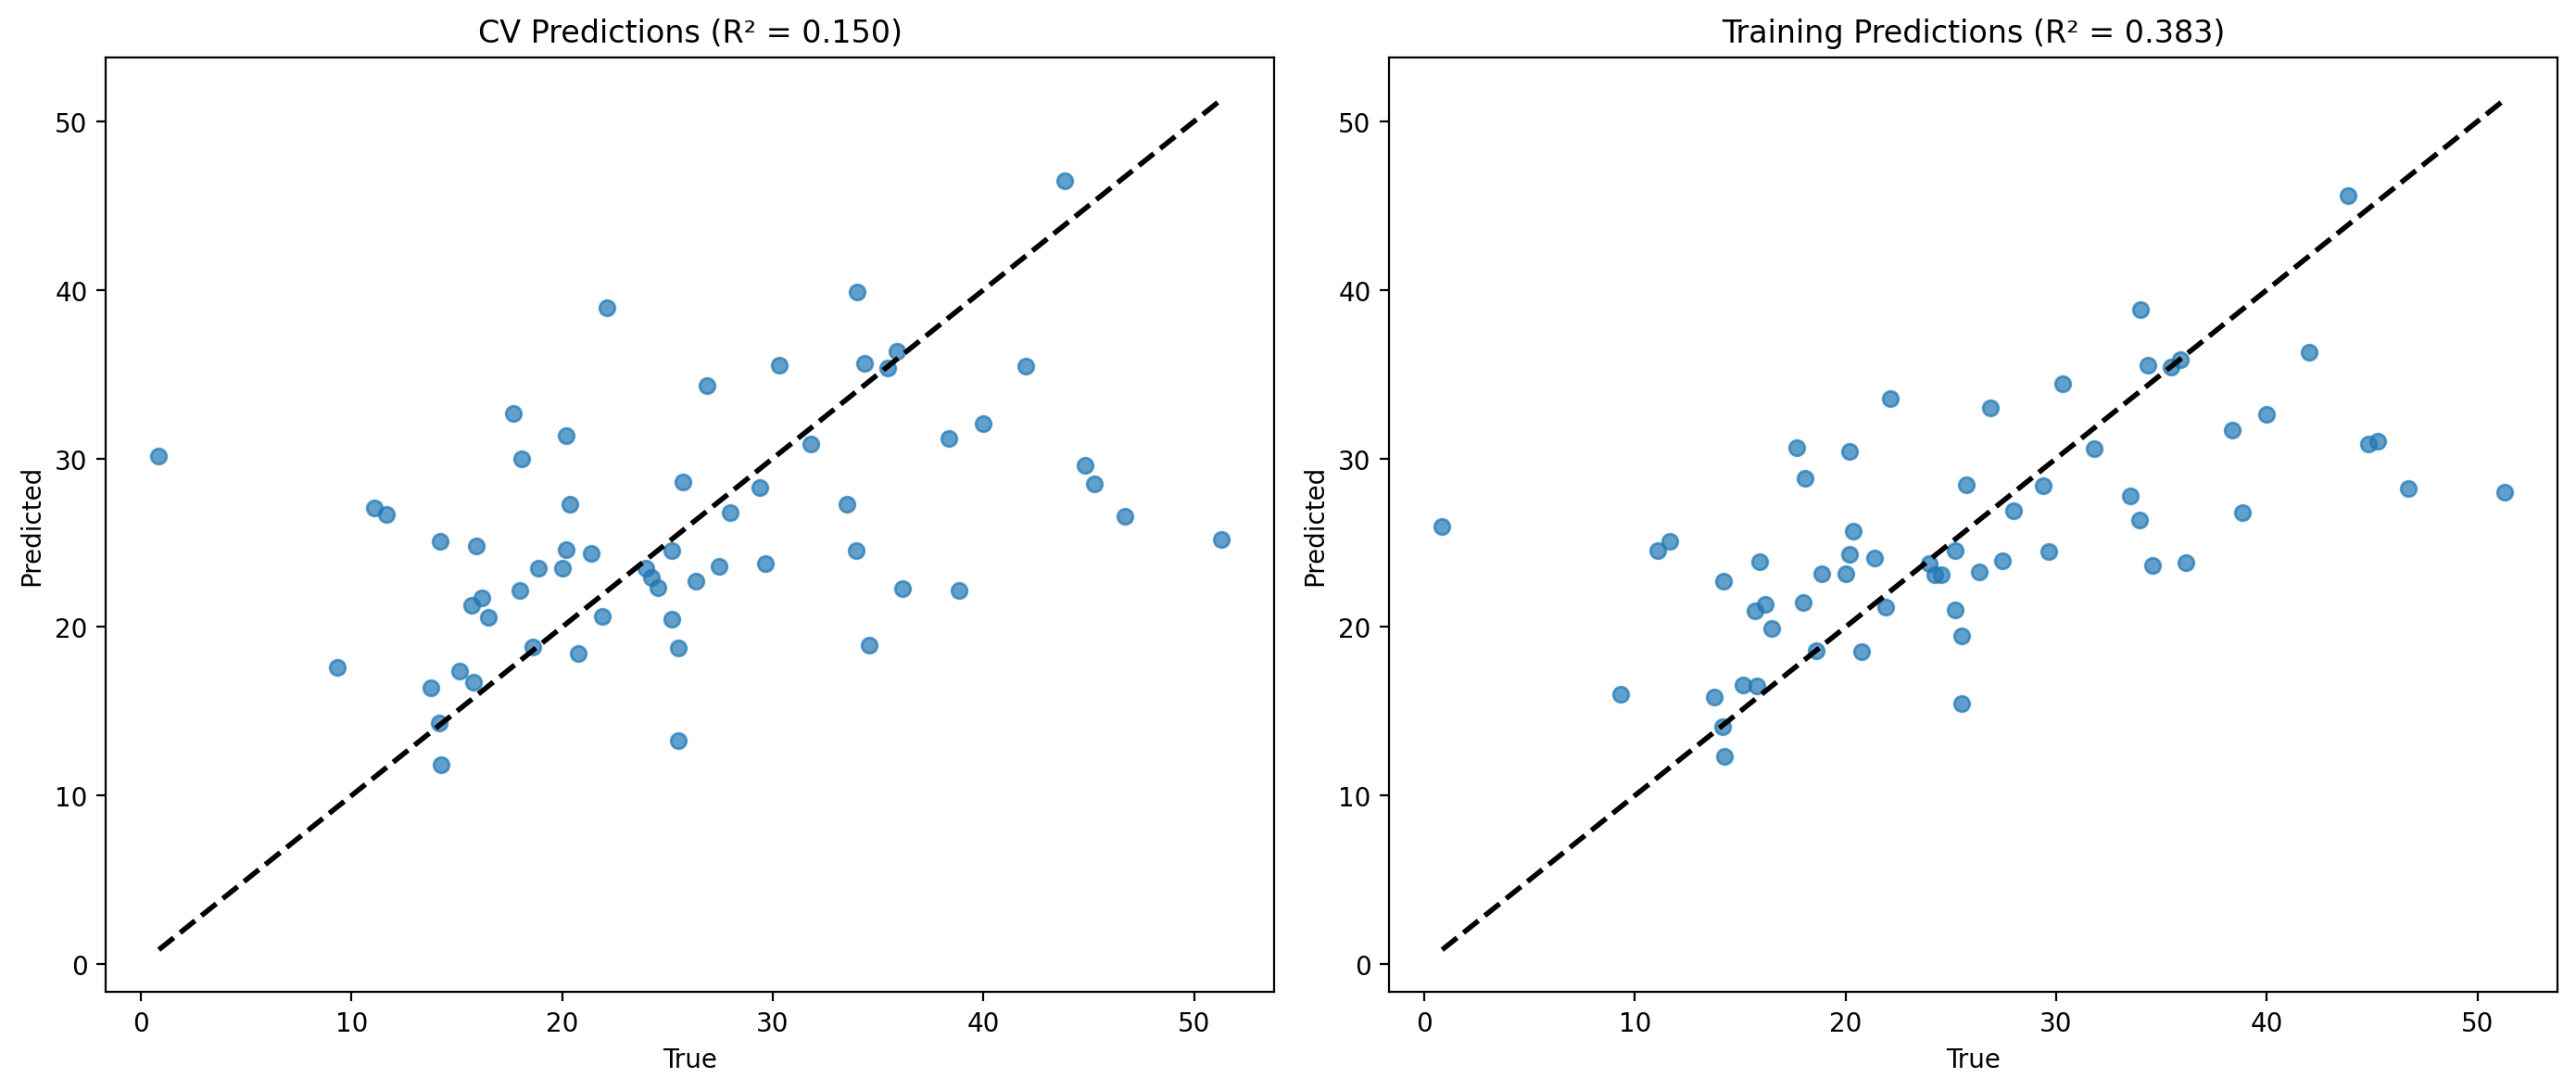

True values:
[26.34954724 33.99667535 17.99490898 33.50394666 15.76649824 16.51028851
 27.4392041  38.8477682  29.66636901 35.44891552 43.84565663 31.78781641
 38.37733982 51.28598531 29.36109105 34.37174351 41.98709092 35.90547132
 26.88588344 30.31833791 11.66227406  0.84665878 36.15292254 46.72183429
 24.2137897  25.22086625 25.20186465 23.95288859 44.8004844  11.07052374
 20.34175941 34.58598935 33.96308297 21.39273373 20.7741465  18.88236324
 20.00041174 14.14179187 24.56281429  9.33677332 45.25372656 15.11219897
 25.7345696  27.96738696 22.10416731 18.0778696  14.18246055 13.7436505
 14.25240546 20.17142599 16.18232383 39.96557731 25.49774091 15.69696205
 18.60065302 17.68710056 20.17013219 15.92514102 21.90811596 25.5081491 ]
CV predictions:
[22.74150906 39.88287065 22.16258097 27.26121132 16.7408319  20.56563664
 23.60260088 22.17606726 23.76036312 35.38936703 46.47016874 30.87140995
 31.18563138 25.19163227 28.25368479 35.63459954 35.45678881 36.33305287
 34.31350612 35.505481

In [38]:
# Check the CV predictions more carefully
best_n_comp = np.argmax(r2s) + 1
pred_vals_cv, r2_cv, rmse_cv, rpd_cv = optimise_pls_cv(
    Xvals, yvals, best_n_comp, cv=LeaveOneOut()
)

# Train on all and predict on all
pls_final = PLSRegression(n_components=best_n_comp)
pls_final.fit(Xvals, yvals)
pred_vals_train = pls_final.predict(Xvals)

# Compare side by side
print(f"CV R²: {r2_cv}")
print(f"Training R²: {r2_score(yvals, pred_vals_train.flatten())}")

# Plot both on the same figure to see the difference
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

ax1.scatter(yvals, pred_vals_cv, alpha=0.7)
ax1.plot([yvals.min(), yvals.max()], [yvals.min(), yvals.max()], "k--", lw=2)
ax1.set_title(f"CV Predictions (R² = {r2_cv:.3f})")
ax1.set_xlabel("True")
ax1.set_ylabel("Predicted")

ax2.scatter(yvals, pred_vals_train, alpha=0.7)
ax2.plot([yvals.min(), yvals.max()], [yvals.min(), yvals.max()], "k--", lw=2)
ax2.set_title(f"Training Predictions (R² = {r2_score(yvals, pred_vals_train):.3f})")
ax2.set_xlabel("True")
ax2.set_ylabel("Predicted")

plt.tight_layout()
plt.show()

#print out predited and true values for each station
print("True values:")
print(yvals)
print("CV predictions:")
print(pred_vals_cv.flatten())
print("Training predictions:")
print(pred_vals_train.flatten())


CV predictions (first 10):
[22.74150906 39.88287065 22.16258097 27.26121132 16.7408319  20.56563664
 23.60260088 22.17606726 23.76036312 35.38936703]

Training predictions (first 10):
[23.27370231 38.80472956 21.4499225  27.75462342 16.49952695 19.91701336
 23.94680151 26.76541598 24.47945252 35.43342315]

Are they identical?
False

CV residual std: 9.690
Training residual std: 8.255


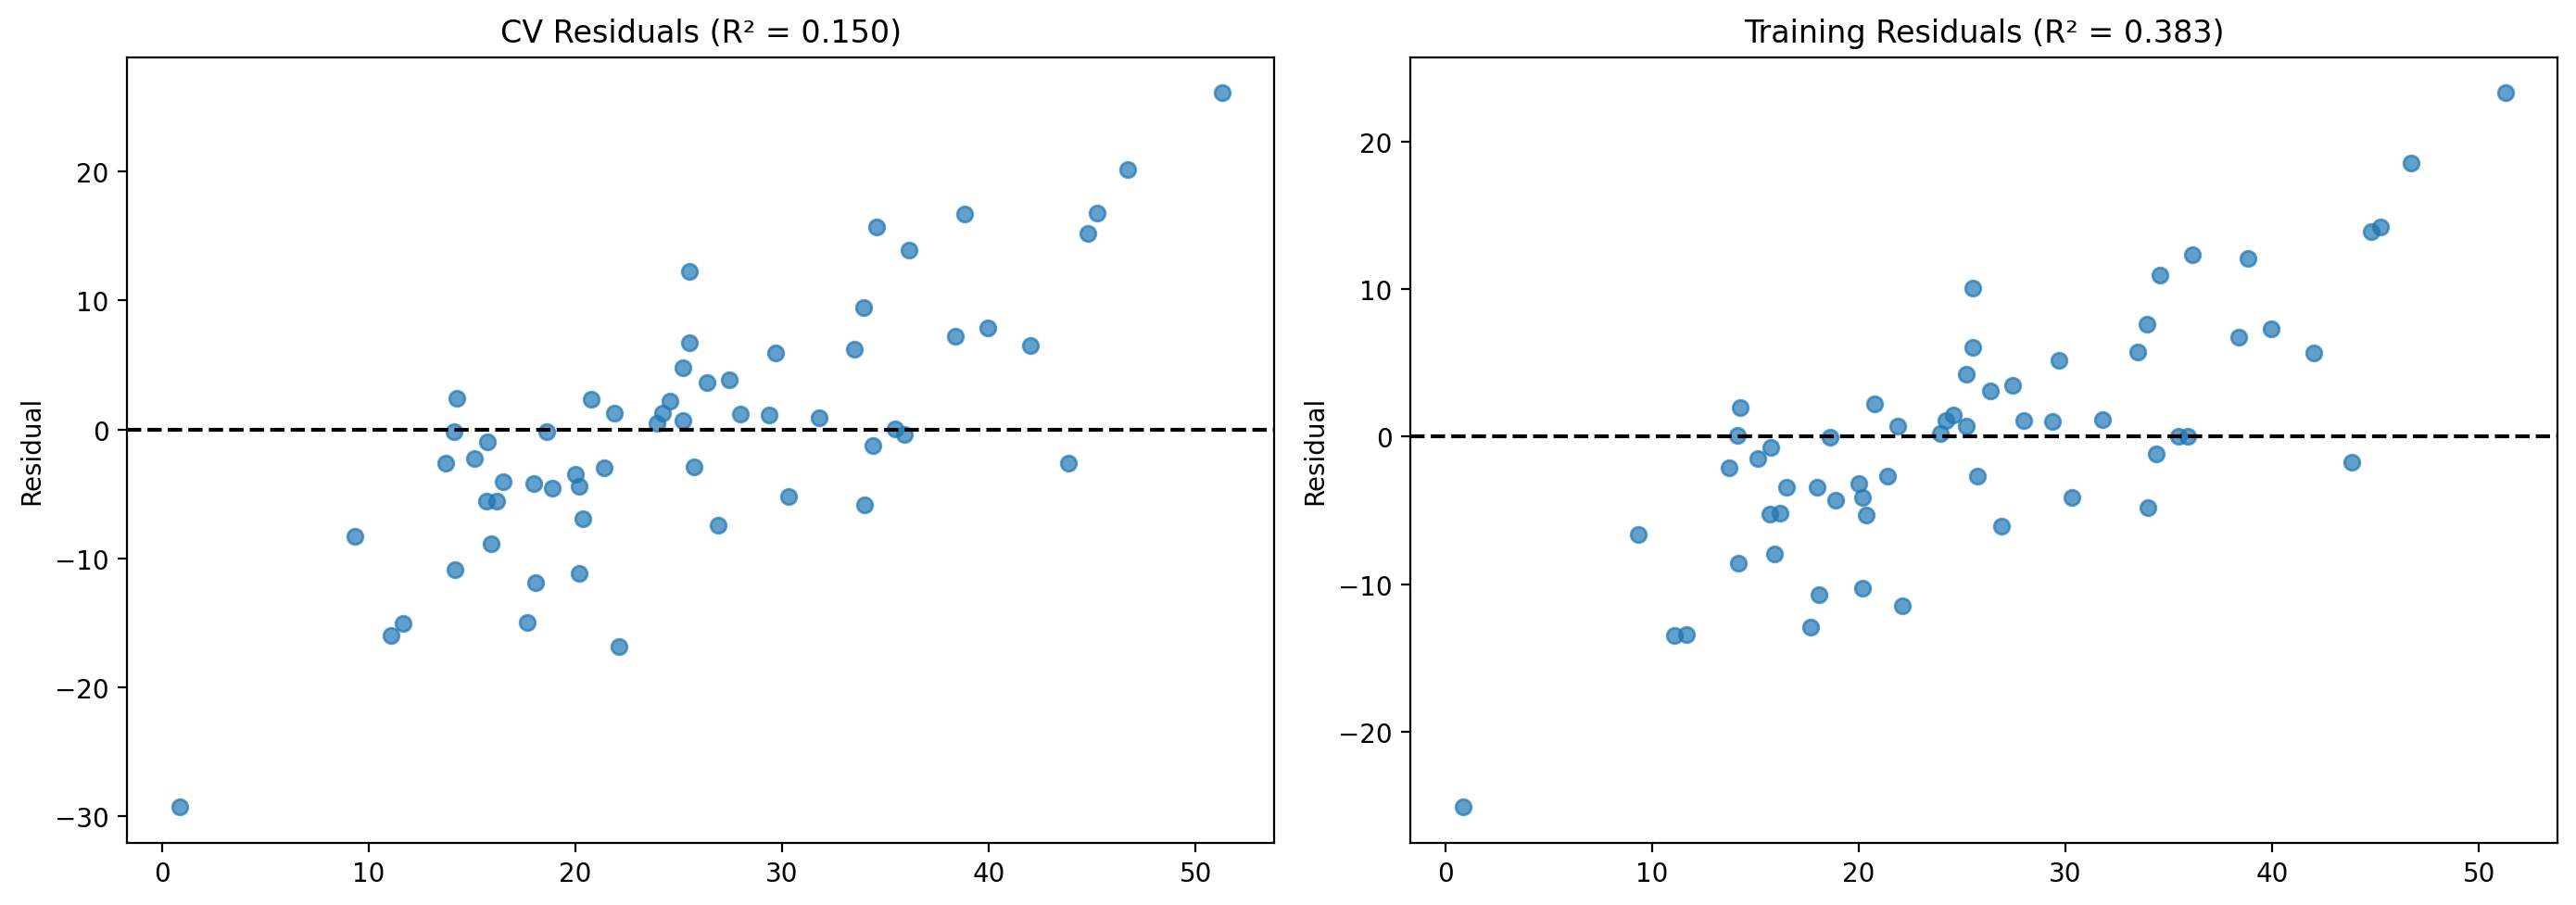

In [39]:
# Verify the predictions are actually different
print("CV predictions (first 10):")
print(pred_vals_cv[:10].flatten())
print("\nTraining predictions (first 10):")
print(pred_vals_train[:10].flatten())

print("\nAre they identical?")
print(np.allclose(pred_vals_cv, pred_vals_train))

# Check residuals
cv_residuals = yvals - pred_vals_cv.flatten()
train_residuals = yvals - pred_vals_train.flatten()

print(f"\nCV residual std: {cv_residuals.std():.3f}")
print(f"Training residual std: {train_residuals.std():.3f}")

# Plot residuals instead
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.scatter(yvals, cv_residuals, alpha=0.7)
ax1.axhline(0, color="k", linestyle="--")
ax1.set_title(f"CV Residuals (R² = {r2_cv:.3f})")
ax1.set_ylabel("Residual")

ax2.scatter(yvals, train_residuals, alpha=0.7)
ax2.axhline(0, color="k", linestyle="--")
ax2.set_title(f"Training Residuals (R² = {r2_score(yvals, pred_vals_train):.3f})")
ax2.set_ylabel("Residual")

plt.tight_layout()
plt.show()
